# Анализ эмоций в отзывах покупателей (Sentiment Analysis) для вьетнамского языка

## Цель
Построение системы глубокого обучения для **многоклассовой классификации эмоций**
в отзывах на вьетнамском языке (e-commerce платформа Tiki):
- **Happiness** (радость, удовлетворённость)
- **Disgust** (недовольство, отвращение)
- **Surprise** (удивление)
- **Sadness** (грусть)
- **Anger** (гнев)
- **Fear** (страх, опасение)

## Методика (Deep Learning)
1. Разведочный анализ данных (EDA)
2. Предобработка (нормализация teencode + очистка + удаление стоп-слов)
3. Представление текста: Keras Tokenizer + Padding
4. Обучение и сравнение четырёх нейросетевых моделей:
   - **MLP** (Embedding + Pooling)
   - **1D CNN**
   - 
   - **BiLSTM**
   - **CNN + BiLSTM** (гибрид)
5. Сравнение качества, анализ ошибок, демо инференса, сохранение артефактов

In [1]:
# Установка библиотеки underthesea для сегментации вьетнамских слов
!pip install underthesea -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 31.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.7 MB/s eta 0:00:0000:01


In [2]:
# ============================================================
# Импорт необходимых библиотек
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Библиотеки обработки текста
import re
import string
from collections import Counter
import random
import unicodedata
import time
import os
import pickle
import json

# Библиотеки машинного обучения (оценка качества и предобработка)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight

# TensorFlow / Keras для нейросетевых моделей
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import AdamW

# Сегментация вьетнамских слов
from underthesea import word_tokenize

print('Все библиотеки успешно импортированы.')
print(f'TensorFlow: {tf.__version__}')

Все библиотеки успешно импортированы.
TensorFlow: 2.20.0


In [3]:
# ============================================================
# Проверка и настройка GPU на Kaggle
# ============================================================
print('ПРОВЕРКА GPU')
print('=' * 50)
physical_devices = tf.config.list_physical_devices('GPU')
print('Доступно GPU:', len(physical_devices))
if physical_devices:
    try:
        for gpu in physical_devices:
            # Динамическое выделение памяти — защита от ошибок нехватки памяти
            tf.config.experimental.set_memory_growth(gpu, True)
        tf.config.set_visible_devices(physical_devices[0], 'GPU')
        print('GPU успешно настроен.')
    except RuntimeError as e:
        print(e)
else:
    print('GPU не найден. Обучение пойдёт на CPU (будет заметно медленнее).')

# Включаем mixed precision для ускорения обучения на GPU
try:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy('mixed_float16')
    print('Mixed precision (float16) включён для ускорения обучения.')
except Exception as e:
    print('Не удалось включить mixed precision:', e)

ПРОВЕРКА GPU
Доступно GPU: 2
GPU успешно настроен.
Mixed precision (float16) включён для ускорения обучения.


In [4]:
# ============================================================
# КОНФИГУРАЦИЯ ЭКСПЕРИМЕНТА
# ============================================================

# --- ПУТИ (настройте под свой датасет на Kaggle!) ---
DATA_PATH = '/kaggle/input/datasets/gnehttran/data-tiki-for-sentiment/data.csv'
TEENCODE_PATH = '/kaggle/working/teencode.txt'   # опциональный словарь teencode
OUTPUT_DIR = '/kaggle/working/artifacts'         # сюда сохраняются модели и компоненты
RESULTS_DIR = '/kaggle/working/results'          # сюда сохраняются метрики для отчёта

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# --- Воспроизводимость результатов ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# --- Гиперпараметры ---
use_augmentation = True      # включить/выключить лёгкую аугментацию текста
augmentation_ratio = 0.2     # доля аугментированных примеров (20% — защита от переобучения)
vocab_size = 20000           # максимальный размер словаря токенизатора
oov_token = '<OOV>'          # токен для неизвестных слов
max_len = 100                # длина последовательности после padding
batch_size = 128             # крупный батч: быстрее обучение, стабильнее градиент
epochs = 20                  # максимум эпох (обычно раньше срабатывает EarlyStopping)
embedding_dim = 128          # размерность векторных представлений слов

print('Конфигурация загружена:')
print(f'  Данные:       {DATA_PATH}')
print(f'  Артефакты:    {OUTPUT_DIR}')
print(f'  Результаты:   {RESULTS_DIR}')
print(f'  Batch/epochs: {batch_size}/{epochs}, max_len={max_len}, emb={embedding_dim}')

Конфигурация загружена:
  Данные:       /kaggle/input/datasets/gnehttran/data-tiki-for-sentiment/data.csv
  Артефакты:    /kaggle/working/artifacts
  Результаты:   /kaggle/working/results
  Batch/epochs: 128/20, max_len=100, emb=128


## 1. Разведочный анализ данных (EDA)

In [5]:
# ============================================================
# Загрузка данных
# ============================================================
df = pd.read_csv(DATA_PATH)

print('ОСНОВНАЯ ИНФОРМАЦИЯ О ДАННЫХ')
print('=' * 50)
print(f'Размер датасета: {df.shape}')
print(f'Количество примеров: {len(df):,}')
print(f'Колонки: {list(df.columns)}')
print(f'Пропущенные значения: {df.isnull().sum().sum()}')

print('\nПЕРВЫЕ ПРИМЕРЫ ДАННЫХ')
print('=' * 50)
display(df.head())

ОСНОВНАЯ ИНФОРМАЦИЯ О ДАННЫХ
Размер датасета: (26382, 2)
Количество примеров: 26,382
Колонки: ['content', 'lable']
Пропущенные значения: 0

ПЕРВЫЕ ПРИМЕРЫ ДАННЫХ


,content,lable
0,Tôi sử dụng rất ít mà đã hỏng không vào điện.\...,surprise
1,"Mình bị mất dây sạc, mua xong 2 năm rồi ko dùn...",disgust
2,"Tôi quên ko bỏ dây nạp vào hộp dề trả lại, tôi...",surprise
3,"Máy dùng sau gần 1 năm có vấn đề về pin, được ...",happiness
4,Khi mơi dùng tia nước khá mạnh và sạch kẽ răng...,disgust


In [6]:
# ============================================================
# Анализ распределения классов эмоций
# ============================================================
print('АНАЛИЗ РАСПРЕДЕЛЕНИЯ КЛАССОВ ЭМОЦИЙ')
print('=' * 50)

# Количество и доля примеров каждого класса
emotion_counts = df['lable'].value_counts()
emotion_props = df['lable'].value_counts(normalize=True) * 100

print('Количество и доля примеров по классам:')
for emotion, count in emotion_counts.items():
    print(f'  {emotion:10s}: {count:5,} примеров ({emotion_props[emotion]:5.1f}%)')

print(f'\nВсего классов эмоций: {len(emotion_counts)}')
print(f'Самый маленький класс: {emotion_counts.min():,} примеров')
print(f'Самый большой класс:   {emotion_counts.max():,} примеров')
print(f'Коэффициент дисбаланса: {emotion_counts.max()/emotion_counts.min():.1f}:1')

АНАЛИЗ РАСПРЕДЕЛЕНИЯ КЛАССОВ ЭМОЦИЙ
Количество и доля примеров по классам:
  surprise  : 4,784 примеров ( 18.1%)
  happiness : 4,784 примеров ( 18.1%)
  anger     : 4,784 примеров ( 18.1%)
  sadness   : 4,784 примеров ( 18.1%)
  fear      : 4,484 примеров ( 17.0%)
  disgust   : 2,762 примеров ( 10.5%)

Всего классов эмоций: 6
Самый маленький класс: 2,762 примеров
Самый большой класс:   4,784 примеров
Коэффициент дисбаланса: 1.7:1


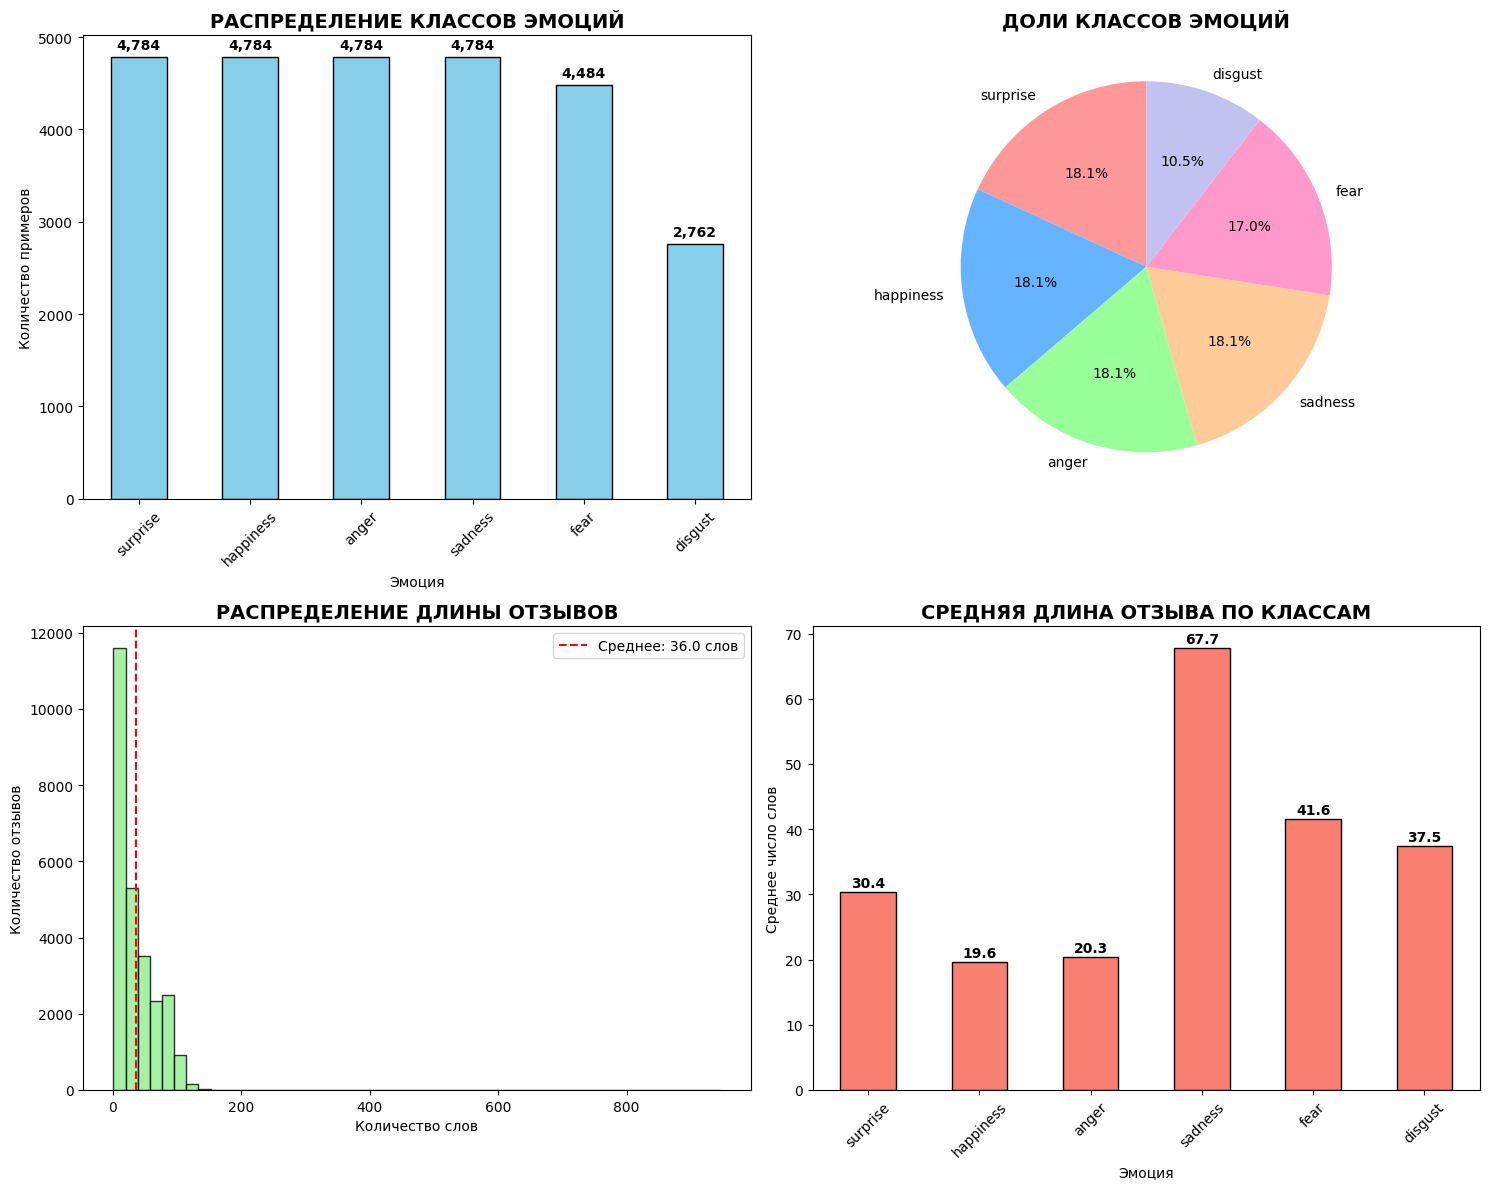

In [7]:
# Визуализация распределения данных
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# 1. Столбчатая диаграмма количества примеров по классам
emotion_counts.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')
ax1.set_title('РАСПРЕДЕЛЕНИЕ КЛАССОВ ЭМОЦИЙ', fontsize=14, fontweight='bold')
ax1.set_xlabel('Эмоция'); ax1.set_ylabel('Количество примеров')
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(emotion_counts.values):
    ax1.text(i, v + 50, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# 2. Круговая диаграмма долей классов
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc', '#c2c2f0']
ax2.pie(emotion_counts.values, labels=emotion_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
ax2.set_title('ДОЛИ КЛАССОВ ЭМОЦИЙ', fontsize=14, fontweight='bold')

# 3. Распределение длины отзывов (в словах)
word_lengths = df['content'].astype(str).str.split().str.len()
ax3.hist(word_lengths, bins=50, color='lightgreen', edgecolor='black', alpha=0.8)
ax3.set_title('РАСПРЕДЕЛЕНИЕ ДЛИНЫ ОТЗЫВОВ', fontsize=14, fontweight='bold')
ax3.set_xlabel('Количество слов'); ax3.set_ylabel('Количество отзывов')
ax3.axvline(word_lengths.mean(), color='red', linestyle='--',
            label=f'Среднее: {word_lengths.mean():.1f} слов')
ax3.legend()

# 4. Средняя длина отзыва по классам эмоций
df['word_count'] = word_lengths
avg_len = df.groupby('lable')['word_count'].mean().reindex(emotion_counts.index)
avg_len.plot(kind='bar', ax=ax4, color='salmon', edgecolor='black')
ax4.set_title('СРЕДНЯЯ ДЛИНА ОТЗЫВА ПО КЛАССАМ', fontsize=14, fontweight='bold')
ax4.set_xlabel('Эмоция'); ax4.set_ylabel('Среднее число слов')
ax4.tick_params(axis='x', rotation=45)
for i, v in enumerate(avg_len.values):
    ax4.text(i, v + 0.3, f'{v:.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 2. Предобработка текста (Text Preprocessing)

**Этапы предобработки для вьетнамского языка:**
- Нормализация teencode (интернет-сокращения: «ko» → «không», «dc» → «được» и т.п.)
- Очистка текста (URL, email, телефоны, спецсимволы, эмодзи)
- Нормализация (нижний регистр, замена чисел на токен)
- Сегментация слов библиотекой underthesea (важно для вьетнамского:
  слова могут состоять из нескольких слогов)
- Удаление стоп-слов вьетнамского языка

In [8]:
# ============================================================
# Шаг 1. Нормализация teencode
# ============================================================
import time

# «Чёрный список» одно-двухбуквенных сокращений: их автоматическая замена
# часто порождает ошибки (например, 'k' -> 'không' внутри обычных слов),
# поэтому такие ключи словаря пропускаются
TEENCODE_BLACKLIST = {'c', 'k', 'n', 'ng', 'a', 'e', 'h', 'o', 'dc', 'x', 't', 'b'}

def load_teencode_dict(path):
    """Загружает словарь teencode -> нормальная форма из TSV-файла.
    Если файл не найден, возвращается пустой словарь (шаг пропускается)."""
    teencode_dict = {}
    try:
        with open(path, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split('\t')
                if len(parts) == 2:
                    key, value = parts[0].strip().lower(), parts[1].strip()
                    # Безопасная логика: пропускаем чёрный список и слишком короткие слова
                    if key in TEENCODE_BLACKLIST or (len(key) < 2 and key.isalpha()):
                        continue
                    teencode_dict[key] = value
        print(f'Загружено и отфильтровано {len(teencode_dict)} пар teencode.')
    except FileNotFoundError:
        print('Файл teencode.txt не найден — нормализация teencode пропускается.')
    except Exception as e:
        print(f'Ошибка чтения файла: {e}')
    return teencode_dict

def normalize_teencode(text, teencode_dict):
    """Заменяет teencode-сокращения нормальными формами.
    Подстановка выполняется только для целых слов (не подстрок)."""
    if not isinstance(text, str) or not text:
        return ''
    # Разбиваем на слова и знаки препинания, сохраняя разделители
    tokens = re.split(r'(\W+)', text)
    return ''.join(teencode_dict.get(tok.lower(), tok) for tok in tokens)

# Загружаем словарь и применяем ко всему датасету
teencode_dict = load_teencode_dict(TEENCODE_PATH)

print('\nНОРМАЛИЗАЦИЯ TEENCODE ВО ВСЁМ ДАТАСЕТЕ...')
print('-' * 60)
start_time = time.time()
df['content_normalized'] = df['content'].apply(lambda x: normalize_teencode(x, teencode_dict))
duration = time.time() - start_time

changed_rows = (df['content'] != df['content_normalized']).sum()
print(f'Обработано {len(df):,} строк за {duration:.2f} с.')
print(f'Изменено строк: {changed_rows:,} ({changed_rows/len(df)*100:.1f}%)')

Файл teencode.txt не найден — нормализация teencode пропускается.

НОРМАЛИЗАЦИЯ TEENCODE ВО ВСЁМ ДАТАСЕТЕ...
------------------------------------------------------------
Обработано 26,382 строк за 0.72 с.
Изменено строк: 0 (0.0%)


In [9]:
# ============================================================
# Шаг 2. Очистка текста и удаление стоп-слов
# ============================================================

def clean_text(text):
    """Базовая очистка вьетнамского текста отзыва."""
    if pd.isna(text):
        return ''
    text = str(text)

    # Удаляем URL, email и номера телефонов
    text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'[\+]?[1-9]?[0-9]{7,15}', '', text)

    # Заменяем числа специальным токеном ДО удаления спецсимволов
    # (угловые скобки вида <NUM> были бы удалены следующим regex'ом)
    text = re.sub(r'\d+', ' number_token ', text)

    # Оставляем только буквы (включая вьетнамскую диакритику), цифры, пробелы и '_'
    text = re.sub(r'[^\w\s\u00C0-\u1EF9_]', ' ', text)

    # Нормализуем пробелы и приводим к нижнему регистру
    text = re.sub(r'\s+', ' ', text)
    return text.lower().strip()

# Базовый список стоп-слов вьетнамского языка (+ служебные слова домена e-commerce)
vietnamese_stopwords = set([
    'tôi', 'mình', 'tao', 'mày', 'họ', 'nó', 'chúng', 'ta', 'chúng_tôi', 'chúng_ta',
    'bạn', 'anh', 'chị', 'em', 'cô', 'chú', 'bác', 'ông', 'bà',
    'và', 'với', 'của', 'trong', 'tại', 'ở', 'trên', 'dưới', 'cho', 'về',
    'là', 'có', 'được', 'bị', 'phải', 'đã', 'đang', 'sẽ', 'vẫn', 'còn',
    'như', 'nhưng', 'thì', 'mà', 'nếu', 'vì', 'do', 'nên',
    'rất', 'quá', 'lắm', 'cực', 'hơi', 'khá',
    'cái', 'chiếc', 'những', 'các', 'mọi', 'này', 'kia', 'đó',
    'ạ', 'nhé', 'à', 'ừ', 'vâng', 'dạ', 'thôi', 'rồi', 'nhỉ',
    'shop', 'tiki', 'shopee', 'lazada', 'sản_phẩm', 'mua', 'bán'
])

def remove_stopwords(text):
    """Сегментирует текст underthesea и удаляет стоп-слова.
    Пробелы внутри составных слов заменяются на '_', чтобы модель
    воспринимала их как единый токен (например, 'hài lòng' -> 'hài_lòng')."""
    words = word_tokenize(text)
    filtered = [w for w in words if w not in vietnamese_stopwords and len(w) > 1]
    filtered = [w.replace(' ', '_') for w in filtered]
    return ' '.join(filtered)

# Применяем предобработку
print('ПРЕДОБРАБОТКА ТЕКСТА...')
print('=' * 50)
df_processed = df.copy()

print('Пример ДО обработки:')
print(df['content'].iloc[0])

df_processed['content_cleaned'] = df_processed['content_normalized'].apply(clean_text)
df_processed['content_final'] = df_processed['content_cleaned'].apply(remove_stopwords)

print('\nПосле очистки:')
print(df_processed['content_cleaned'].iloc[0])
print('\nПосле удаления стоп-слов:')
print(df_processed['content_final'].iloc[0])

# Удаляем слишком короткие тексты (меньше 2 слов после обработки)
min_words = 2
before = len(df_processed)
df_processed = df_processed[df_processed['content_final'].str.split().str.len() >= min_words]
print(f'\nПримеров после фильтрации: {len(df_processed):,} (удалено {before - len(df_processed):,})')

ПРЕДОБРАБОТКА ТЕКСТА...
Пример ДО обработки:
Tôi sử dụng rất ít mà đã hỏng không vào điện.
Tôi có được bảo hành không? 
Nếu được bảo hành tôi gửi theo đc nào? Hãy hướng dẫn

После очистки:
tôi sử dụng rất ít mà đã hỏng không vào điện tôi có được bảo hành không nếu được bảo hành tôi gửi theo đc nào hãy hướng dẫn

После удаления стоп-слов:
sử_dụng ít hỏng không vào điện bảo_hành không bảo_hành gửi theo đc nào hãy hướng_dẫn

Примеров после фильтрации: 26,176 (удалено 206)


In [10]:
# ============================================================
# Шаг 3. Подготовка данных: кодирование меток и разбиение
# Разбиение выполняется ОДИН раз — все модели сравниваются честно
# ============================================================
print('ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛЕЙ')
print('=' * 50)

# Кодируем метки эмоций числами
label_encoder = LabelEncoder()
df_processed['label_encoded'] = label_encoder.fit_transform(df_processed['lable'])

print('СООТВЕТСТВИЕ КЛАССОВ И КОДОВ:')
for i, label in enumerate(label_encoder.classes_):
    count = (df_processed['label_encoded'] == i).sum()
    print(f'  {i}: {label} ({count:,} примеров)')

# Стратифицированное разбиение train/test (80/20)
X = df_processed['content_final'].values
y = df_processed['label_encoded'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

print(f'\nРАЗБИЕНИЕ ДАННЫХ:')
print(f'  Обучающая выборка: {len(X_train):,} примеров')
print(f'  Тестовая выборка:  {len(X_test):,} примеров')
print(f'  Количество классов: {len(label_encoder.classes_)}')

print(f'\nРАСПРЕДЕЛЕНИЕ КЛАССОВ В TRAIN:')
train_distribution = pd.Series(y_train).value_counts().sort_index()
for i, count in enumerate(train_distribution):
    print(f'  {label_encoder.classes_[i]}: {count:,} ({count/len(y_train)*100:.1f}%)')

# Веса классов для компенсации дисбаланса (класс disgust недопредставлен)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))
print(f'\nВеса классов: {class_weights_dict}')

ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛЕЙ
СООТВЕТСТВИЕ КЛАССОВ И КОДОВ:
  0: anger (4,779 примеров)
  1: disgust (2,757 примеров)
  2: fear (4,484 примеров)
  3: happiness (4,647 примеров)
  4: sadness (4,782 примеров)
  5: surprise (4,727 примеров)

РАЗБИЕНИЕ ДАННЫХ:
  Обучающая выборка: 20,940 примеров
  Тестовая выборка:  5,236 примеров
  Количество классов: 6

РАСПРЕДЕЛЕНИЕ КЛАССОВ В TRAIN:
  anger: 3,823 (18.3%)
  disgust: 2,206 (10.5%)
  fear: 3,587 (17.1%)
  happiness: 3,718 (17.8%)
  sadness: 3,825 (18.3%)
  surprise: 3,781 (18.1%)

Веса классов: {0: np.float64(0.9128956317028512), 1: np.float64(1.5820489573889394), 2: np.float64(0.9729579035405631), 3: np.float64(0.9386767079074771), 4: np.float64(0.9124183006535947), 5: np.float64(0.9230362338005819)}


In [11]:
# ============================================================
# Шаг 4. Лёгкая аугментация текста (только обучающая выборка)
# - случайное удаление слов (random deletion)
# - случайная перестановка слов (random swap)
# Не требует внешних библиотек
# ============================================================
def random_deletion(words, p=0.15):
    """Случайно удаляет слова с вероятностью p (повышает устойчивость к шуму)."""
    if len(words) == 1:
        return words
    kept = [w for w in words if random.uniform(0, 1) > p]
    return kept if kept else [random.choice(words)]

def random_swap(words, n_swaps=2):
    """Случайно меняет местами n_swaps пар слов."""
    words = words.copy()
    for _ in range(n_swaps):
        i = random.randint(0, len(words) - 1)
        j = random.randint(0, len(words) - 1)
        words[i], words[j] = words[j], words[i]
    return words

def augment_text(text):
    """Применяет одну из двух аугментаций к тексту."""
    tokens = text.split()
    if len(tokens) < 2:
        return text
    if random.choice(['del', 'swap']) == 'del':
        tokens = random_deletion(tokens, p=0.15)
    else:
        tokens = random_swap(tokens, n_swaps=2)
    return ' '.join(tokens)

# Формируем аугментированную обучающую выборку
if use_augmentation:
    n_aug = int(len(X_train) * augmentation_ratio)
    idxs = np.random.choice(len(X_train), n_aug, replace=False)
    X_aug_texts = [augment_text(X_train[i]) for i in idxs]
    y_aug = y_train[idxs]
    X_train_aug = np.concatenate([X_train, np.array(X_aug_texts)], axis=0)
    y_train_aug = np.concatenate([y_train, y_aug], axis=0)
    print(f'Аугментация: добавлено {n_aug:,} примеров -> размер train: {len(X_train_aug):,}')
else:
    X_train_aug, y_train_aug = X_train, y_train
    print('Аугментация отключена.')

Аугментация: добавлено 4,188 примеров -> размер train: 25,128


In [12]:
# ============================================================
# Шаг 5. Токенизация Keras + Padding
# ============================================================
print('ПОДГОТОВКА ДАННЫХ ДЛЯ DEEP LEARNING (Tokenizer + Padding)')
print('=' * 70)

# По умолчанию Keras Tokenizer удаляет '_' — исправляем filters,
# чтобы сохранить склейку составных слов (например, 'hài_lòng')
custom_filters = '!"#$%&()*+,-./:;<=>?@[\\]^`{|}~\t\n'  # без '_'

tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_token, filters=custom_filters)
# Обучаем токенизатор только на train (с аугментацией, если включена)
tokenizer.fit_on_texts(X_train_aug)

# Преобразуем тексты в последовательности индексов
X_train_seq = tokenizer.texts_to_sequences(X_train_aug)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Приводим последовательности к фиксированной длине
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

num_classes = len(label_encoder.classes_)
print(f'Количество классов: {num_classes}')
print(f'Фактический размер словаря: {min(vocab_size, len(tokenizer.word_index)+1):,}')
print(f'X_train_pad: {X_train_pad.shape}, X_test_pad: {X_test_pad.shape}')

ПОДГОТОВКА ДАННЫХ ДЛЯ DEEP LEARNING (Tokenizer + Padding)
Количество классов: 6
Фактический размер словаря: 9,474
X_train_pad: (25128, 100), X_test_pad: (5236, 100)


## 3. Построение нейросетевых моделей

В этом разделе строятся и сравниваются четыре архитектуры глубокого обучения:
1. **1D CNN** — свёрточная сеть для извлечения локальных n-граммных признаков
2. **BiLSTM** — двунаправленная рекуррентная сеть для учёта контекста
3. **CNN + BiLSTM** — гибрид: свёртки + рекуррентность
4. **MLP** — полносвязная сеть поверх усреднённых эмбеддингов

Все модели обучаются на одних и тех же данных (Tokenizer + Padding).

In [13]:
# ============================================================
# Вспомогательные функции обучения и визуализации
# ============================================================
print('ОБУЧЕНИЕ МОДЕЛЕЙ DEEP LEARNING')
print('=' * 60)

def compile_and_train(model, X_tr, y_tr, X_va, y_va, name):
    """Компилирует и обучает модель с ранней остановкой.
    AdamW с weight decay снижает переобучение; EarlyStopping возвращает
    лучшие веса по val_loss; ReduceLROnPlateau понижает шаг при стагнации."""
    model.compile(optimizer=AdamW(learning_rate=5e-4, weight_decay=0.01),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                          restore_best_weights=True)
    rlrop = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                                                 patience=2, verbose=1)
    history = model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                        batch_size=batch_size, epochs=epochs,
                        callbacks=[es, rlrop], class_weight=class_weights_dict,
                        verbose=2)
    print(f'\n{name} — обучение завершено. Лучший val_acc: {max(history.history["val_accuracy"]):.4f}')
    return history

def plot_confusion_matrix(y_true, y_pred, model_name, class_names):
    """Строит матрицу ошибок для одной модели."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Матрица ошибок — {model_name}', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Предсказанный класс'); plt.ylabel('Истинный класс')
    plt.tight_layout(); plt.show()

ОБУЧЕНИЕ МОДЕЛЕЙ DEEP LEARNING


### 3.1 Модель 1: 1D CNN

In [14]:
# Два свёрточных блока (Conv-BN-Pool) + классификатор
print('\n[M1] CNN — построение и обучение')
tf.keras.backend.clear_session()  # очищаем сессию во избежание утечек памяти GPU
cnn_model = models.Sequential([
    layers.Embedding(input_dim=min(vocab_size, len(tokenizer.word_index)+1),
                     output_dim=embedding_dim, input_length=max_len),
    layers.SpatialDropout1D(0.3),                      # dropout против переобучения

    layers.Conv1D(128, 3, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),                       # BatchNorm для стабильности обучения
    layers.MaxPooling1D(2),

    layers.Conv1D(128, 3, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.GlobalMaxPooling1D(),

    layers.Dropout(0.5),
    layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(num_classes, activation='softmax', dtype='float32')  # float32 для mixed precision
])
cnn_model.build(input_shape=(None, max_len))
cnn_model.summary()


[M1] CNN — построение и обучение


I0000 00:00:1791309920.054811      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     1,212,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 100, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 98, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 98, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 49, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 47, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 47, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,330,054 (5.07 MB)

 Trainable params: 1,329,286 (5.07 MB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/20


2026-10-06 18:05:27.430409: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 18:05:27.712696: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1791309931.426889     166 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


197/197 - 16s - 81ms/step - accuracy: 0.4350 - loss: 1.6969 - val_accuracy: 0.3344 - val_loss: 2.2703 - learning_rate: 5.0000e-04
Epoch 2/20
197/197 - 1s - 7ms/step - accuracy: 0.8134 - loss: 0.6287 - val_accuracy: 0.4326 - val_loss: 1.4641 - learning_rate: 5.0000e-04
Epoch 3/20
197/197 - 1s - 7ms/step - accuracy: 0.8903 - loss: 0.3990 - val_accuracy: 0.9125 - val_loss: 0.3787 - learning_rate: 5.0000e-04
Epoch 4/20
197/197 - 1s - 7ms/step - accuracy: 0.9173 - loss: 0.3121 - val_accuracy: 0.9301 - val_loss: 0.2626 - learning_rate: 5.0000e-04
Epoch 5/20
197/197 - 1s - 7ms/step - accuracy: 0.9347 - loss: 0.2609 - val_accuracy: 0.9322 - val_loss: 0.2562 - learning_rate: 5.0000e-04
Epoch 6/20
197/197 - 1s - 7ms/step - accuracy: 0.9475 - loss: 0.2183 - val_accuracy: 0.9320 - val_loss: 0.2598 - learning_rate: 5.0000e-04
Epoch 7/20

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
197/197 - 1s - 7ms/step - accuracy: 0.9532 - loss: 0.1903 - val_accuracy: 0.9311 - val_

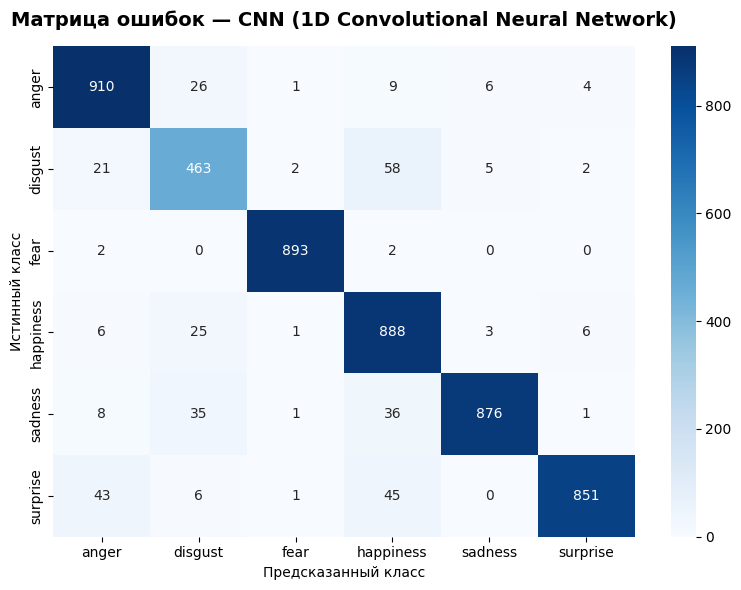

In [15]:
# Обучение и оценка CNN
hist_cnn = compile_and_train(cnn_model, X_train_pad, y_train_aug,
                             X_test_pad, y_test, name='CNN')

y_pred_cnn_prob = cnn_model.predict(X_test_pad)
y_pred_cnn = np.argmax(y_pred_cnn_prob, axis=1)
cnn_accuracy = accuracy_score(y_test, y_pred_cnn)
report_cnn = classification_report(y_test, y_pred_cnn,
                                   target_names=label_encoder.classes_, output_dict=True)
print(f' Accuracy: {cnn_accuracy:.4f}')
print(classification_report(y_test, y_pred_cnn, target_names=label_encoder.classes_))
plot_confusion_matrix(y_test, y_pred_cnn, 'CNN (1D Convolutional Neural Network)',
                      label_encoder.classes_)

### 3.2 Модель 2: BiLSTM

In [16]:
# Два двунаправленных LSTM-слоя с dropout и BatchNorm
print('\n[M2] BiLSTM — построение и обучение')
tf.keras.backend.clear_session()  # очищаем сессию во избежание утечек памяти GPU
bilstm_model = models.Sequential([
    layers.Embedding(input_dim=min(vocab_size, len(tokenizer.word_index)+1),
                     output_dim=embedding_dim, input_length=max_len),
    layers.SpatialDropout1D(0.3),

    # Первый BiLSTM возвращает последовательность для второго слоя
    layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.4, recurrent_dropout=0.4)),
    layers.BatchNormalization(),
    layers.Bidirectional(layers.LSTM(128, return_sequences=False, dropout=0.4, recurrent_dropout=0.4)),
    layers.BatchNormalization(),

    layers.Dropout(0.5),
    layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax', dtype='float32')  # float32 для mixed precision
])
bilstm_model.build(input_shape=(None, max_len))
bilstm_model.summary()


[M2] BiLSTM — построение и обучение


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     1,212,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 100, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 100, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,906,310 (7.27 MB)

 Trainable params: 1,905,030 (7.27 MB)

 Non-trainable params: 1,280 (5.00 KB)

Epoch 1/20
197/197 - 208s - 1s/step - accuracy: 0.4977 - loss: 1.5430 - val_accuracy: 0.4055 - val_loss: 1.5205 - learning_rate: 5.0000e-04
Epoch 2/20
197/197 - 197s - 1s/step - accuracy: 0.8578 - loss: 0.4864 - val_accuracy: 0.9156 - val_loss: 0.3883 - learning_rate: 5.0000e-04
Epoch 3/20
197/197 - 195s - 988ms/step - accuracy: 0.9095 - loss: 0.3329 - val_accuracy: 0.9305 - val_loss: 0.2532 - learning_rate: 5.0000e-04
Epoch 4/20
197/197 - 193s - 978ms/step - accuracy: 0.9297 - loss: 0.2635 - val_accuracy: 0.9314 - val_loss: 0.2571 - learning_rate: 5.0000e-04
Epoch 5/20

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
197/197 - 195s - 992ms/step - accuracy: 0.9409 - loss: 0.2248 - val_accuracy: 0.9341 - val_loss: 0.2654 - learning_rate: 5.0000e-04
Epoch 6/20
197/197 - 191s - 971ms/step - accuracy: 0.9511 - loss: 0.1879 - val_accuracy: 0.9332 - val_loss: 0.2654 - learning_rate: 1.5000e-04
Epoch 7/20

Epoch 7: ReduceLROnPlateau reducing learning rate to 4.5000

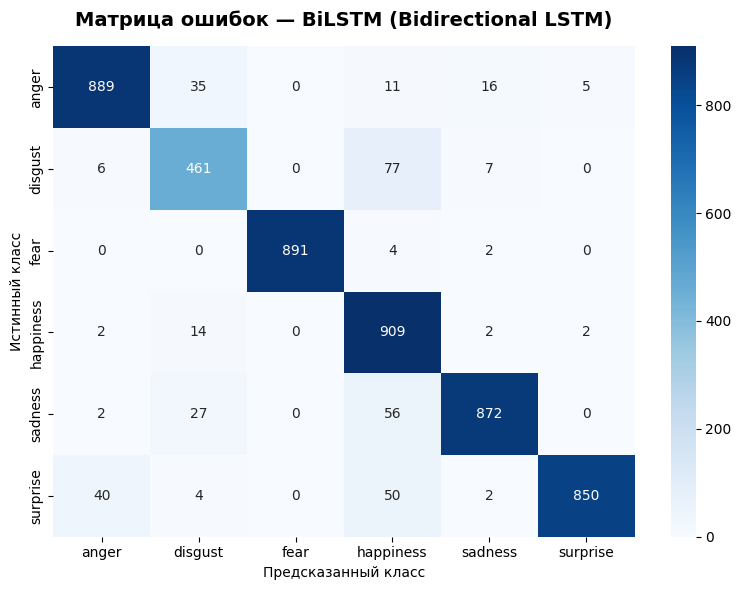

In [17]:
# Обучение и оценка BiLSTM
hist_bilstm = compile_and_train(bilstm_model, X_train_pad, y_train_aug,
                                X_test_pad, y_test, name='BiLSTM')

y_pred_bilstm_prob = bilstm_model.predict(X_test_pad)
y_pred_bilstm = np.argmax(y_pred_bilstm_prob, axis=1)
bilstm_accuracy = accuracy_score(y_test, y_pred_bilstm)
report_bilstm = classification_report(y_test, y_pred_bilstm,
                                      target_names=label_encoder.classes_, output_dict=True)
print(f' Accuracy: {bilstm_accuracy:.4f}')
print(classification_report(y_test, y_pred_bilstm, target_names=label_encoder.classes_))
plot_confusion_matrix(y_test, y_pred_bilstm, 'BiLSTM (Bidirectional LSTM)',
                      label_encoder.classes_)

### 3.3 Модель 3: CNN + BiLSTM (гибрид)

In [18]:
# Гибрид: свёрточный фронтенд извлекает локальные признаки,
# BiLSTM моделирует дальние зависимости поверх них
print('\n[M3] CNN + BiLSTM — построение и обучение')
tf.keras.backend.clear_session()  # очищаем сессию во избежание утечек памяти GPU
input_layer = layers.Input(shape=(max_len,))
x = layers.Embedding(input_dim=min(vocab_size, len(tokenizer.word_index)+1),
                     output_dim=embedding_dim, input_length=max_len)(input_layer)

x = layers.SpatialDropout1D(0.3)(x)
x = layers.Conv1D(128, 3, activation='relu', padding='same',
                  kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(128, 3, activation='relu', padding='same',
                  kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.4,
                                     recurrent_dropout=0.4))(x)
x = layers.BatchNormalization()(x)
x = layers.GlobalMaxPooling1D()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
output_layer = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)
hybrid_model = models.Model(inputs=input_layer, outputs=output_layer)
hybrid_model.summary()


[M3] CNN + BiLSTM — построение и обучение


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 128)       │     1,212,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 100, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 100, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 50, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 50, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,610,630 (6.14 MB)

 Trainable params: 1,609,350 (6.14 MB)

 Non-trainable params: 1,280 (5.00 KB)

Epoch 1/20
197/197 - 58s - 293ms/step - accuracy: 0.3316 - loss: 2.0299 - val_accuracy: 0.1774 - val_loss: 2.6652 - learning_rate: 5.0000e-04
Epoch 2/20
197/197 - 49s - 251ms/step - accuracy: 0.7405 - loss: 0.8618 - val_accuracy: 0.4826 - val_loss: 1.5441 - learning_rate: 5.0000e-04
Epoch 3/20
197/197 - 82s - 417ms/step - accuracy: 0.8878 - loss: 0.4336 - val_accuracy: 0.9211 - val_loss: 0.3381 - learning_rate: 5.0000e-04
Epoch 4/20
197/197 - 49s - 249ms/step - accuracy: 0.9221 - loss: 0.3152 - val_accuracy: 0.9339 - val_loss: 0.2937 - learning_rate: 5.0000e-04
Epoch 5/20
197/197 - 49s - 250ms/step - accuracy: 0.9418 - loss: 0.2481 - val_accuracy: 0.9345 - val_loss: 0.2951 - learning_rate: 5.0000e-04
Epoch 6/20

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
197/197 - 49s - 251ms/step - accuracy: 0.9514 - loss: 0.2064 - val_accuracy: 0.9328 - val_loss: 0.3064 - learning_rate: 5.0000e-04
Epoch 7/20
197/197 - 49s - 248ms/step - accuracy: 0.9613 - loss: 0.1726

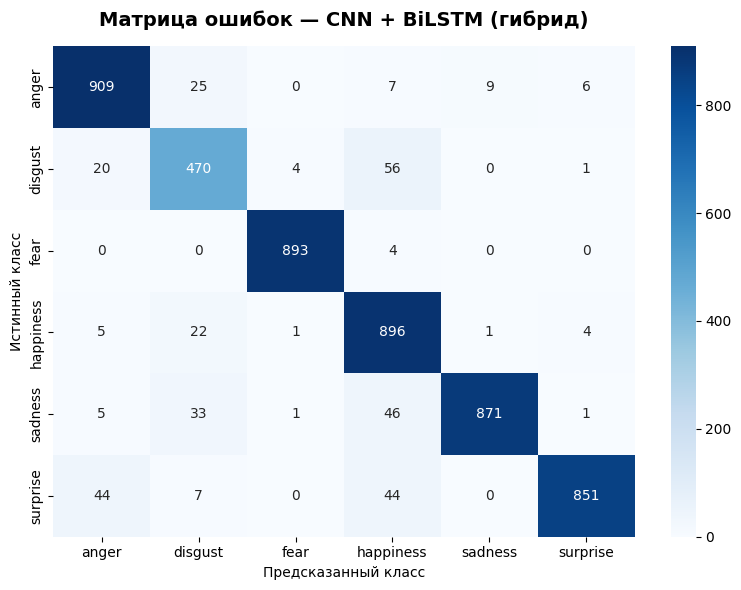

In [19]:
# Обучение и оценка гибридной модели
hist_hybrid = compile_and_train(hybrid_model, X_train_pad, y_train_aug,
                                X_test_pad, y_test, name='CNN+BiLSTM')

y_pred_hybrid_prob = hybrid_model.predict(X_test_pad)
y_pred_hybrid = np.argmax(y_pred_hybrid_prob, axis=1)
hybrid_accuracy = accuracy_score(y_test, y_pred_hybrid)
report_hybrid = classification_report(y_test, y_pred_hybrid,
                                      target_names=label_encoder.classes_, output_dict=True)
print(f' Accuracy: {hybrid_accuracy:.4f}')
print(classification_report(y_test, y_pred_hybrid, target_names=label_encoder.classes_))
plot_confusion_matrix(y_test, y_pred_hybrid, 'CNN + BiLSTM (гибрид)',
                      label_encoder.classes_)

### 3.4 Модель 4: MLP (полносвязная сеть)

In [20]:
# MLP: Embedding -> усреднение по последовательности -> два Dense-блока
print('\n[M4] MLP — построение и обучение')
tf.keras.backend.clear_session()  # очищаем сессию во избежание утечек памяти GPU
nn_model = models.Sequential([
    layers.Embedding(input_dim=min(vocab_size, len(tokenizer.word_index)+1),
                     output_dim=embedding_dim, input_length=max_len),
    layers.GlobalAveragePooling1D(),
    layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax', dtype='float32')  # float32 для mixed precision
])
nn_model.build(input_shape=(None, max_len))
nn_model.summary()


[M4] MLP — построение и обучение


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     1,212,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,280,902 (4.89 MB)

 Trainable params: 1,280,134 (4.88 MB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/20
197/197 - 8s - 40ms/step - accuracy: 0.7694 - loss: 0.7650 - val_accuracy: 0.2303 - val_loss: 1.7304 - learning_rate: 5.0000e-04
Epoch 2/20
197/197 - 1s - 5ms/step - accuracy: 0.9281 - loss: 0.2806 - val_accuracy: 0.6591 - val_loss: 1.1763 - learning_rate: 5.0000e-04
Epoch 3/20
197/197 - 1s - 4ms/step - accuracy: 0.9490 - loss: 0.2024 - val_accuracy: 0.8917 - val_loss: 0.4061 - learning_rate: 5.0000e-04
Epoch 4/20
197/197 - 1s - 4ms/step - accuracy: 0.9598 - loss: 0.1598 - val_accuracy: 0.7691 - val_loss: 0.6937 - learning_rate: 5.0000e-04
Epoch 5/20

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
197/197 - 1s - 4ms/step - accuracy: 0.9651 - loss: 0.1387 - val_accuracy: 0.8803 - val_loss: 0.5712 - learning_rate: 5.0000e-04
Epoch 6/20
197/197 - 1s - 4ms/step - accuracy: 0.9752 - loss: 0.1030 - val_accuracy: 0.9269 - val_loss: 0.3098 - learning_rate: 1.5000e-04
Epoch 7/20
197/197 - 1s - 4ms/step - accuracy: 0.9764 - loss: 0.0960 - val_accuracy: 0.9

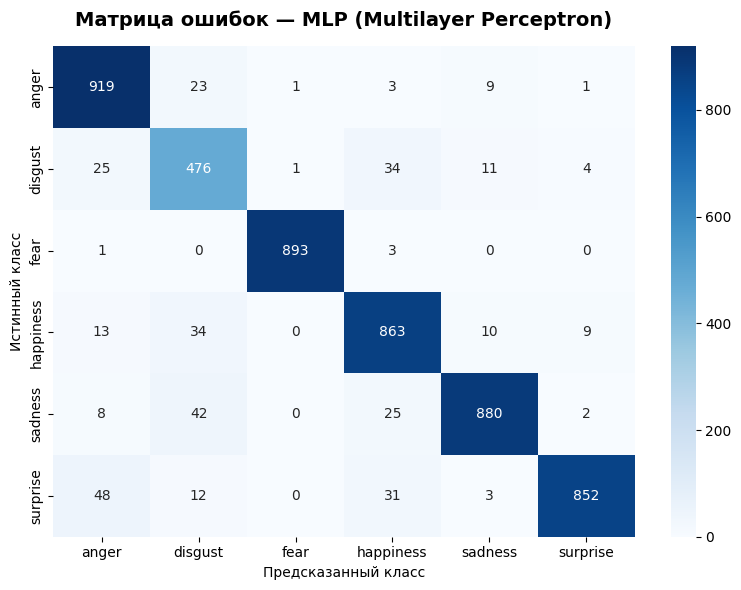

In [21]:
# Обучение и оценка MLP
hist_mlp = compile_and_train(nn_model, X_train_pad, y_train_aug,
                             X_test_pad, y_test, name='MLP')

y_pred_nn_prob = nn_model.predict(X_test_pad)
y_pred_nn = np.argmax(y_pred_nn_prob, axis=1)
nn_accuracy = accuracy_score(y_test, y_pred_nn)
report_nn = classification_report(y_test, y_pred_nn,
                                  target_names=label_encoder.classes_, output_dict=True)
print(f' Accuracy: {nn_accuracy:.4f} ({nn_accuracy*100:.2f}%)')
print(classification_report(y_test, y_pred_nn, target_names=label_encoder.classes_))
plot_confusion_matrix(y_test, y_pred_nn, 'MLP (Multilayer Perceptron)',
                      label_encoder.classes_)

ГРАФИКИ ПРОЦЕССА ОБУЧЕНИЯ


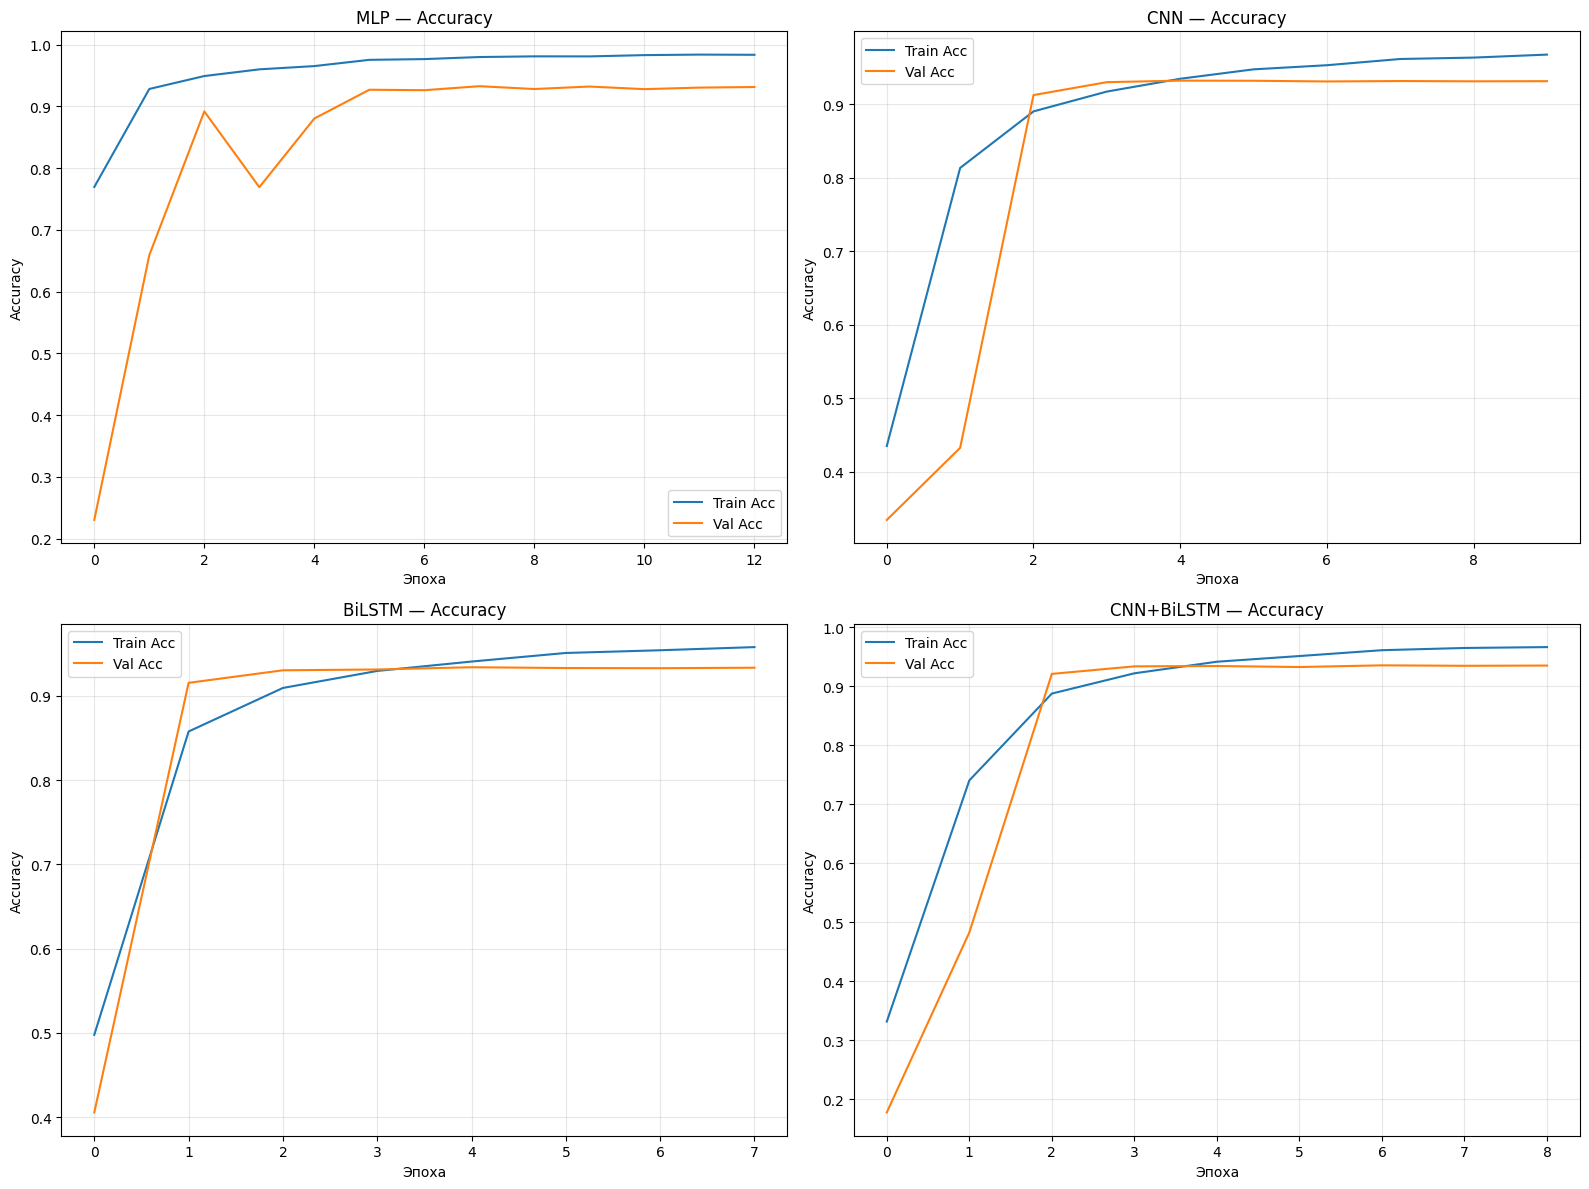

In [22]:
# ============================================================
# Кривые обучения всех четырёх моделей
# ============================================================
print('ГРАФИКИ ПРОЦЕССА ОБУЧЕНИЯ')
print('=' * 50)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
histories = [('MLP', hist_mlp), ('CNN', hist_cnn),
             ('BiLSTM', hist_bilstm), ('CNN+BiLSTM', hist_hybrid)]

for ax, (name, hist) in zip(axes.flat, histories):
    ax.plot(hist.history['accuracy'], label='Train Acc')
    ax.plot(hist.history['val_accuracy'], label='Val Acc')
    ax.set_title(f'{name} — Accuracy')
    ax.set_xlabel('Эпоха'); ax.set_ylabel('Accuracy')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Сравнение качества моделей

СРАВНЕНИЕ КАЧЕСТВА МОДЕЛЕЙ DEEP LEARNING
     Model  Accuracy  Precision (macro)  Recall (macro)  F1-Score (macro)
       MLP    0.9326             0.9267          0.9283            0.9268
       CNN    0.9322             0.9286          0.9264            0.9265
    BiLSTM    0.9305             0.9299          0.9247            0.9256
CNN+BiLSTM    0.9339             0.9312          0.9289            0.9289

ЛУЧШАЯ МОДЕЛЬ: CNN+BiLSTM
Accuracy: 0.9339 (93.39%)


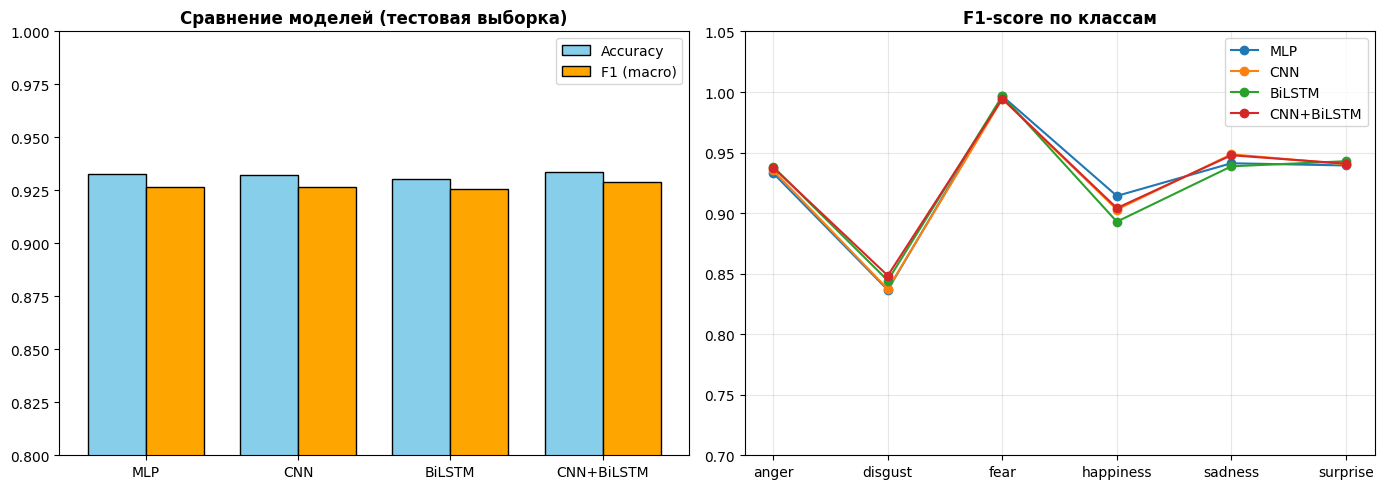

In [23]:
# ============================================================
# Сводная таблица сравнения моделей Deep Learning
# ============================================================
print('СРАВНЕНИЕ КАЧЕСТВА МОДЕЛЕЙ DEEP LEARNING')
print('=' * 60)

models_comparison = {
    'Model': ['MLP', 'CNN', 'BiLSTM', 'CNN+BiLSTM'],
    'Accuracy': [nn_accuracy, cnn_accuracy, bilstm_accuracy, hybrid_accuracy],
    'Precision (macro)': [report_nn['macro avg']['precision'], report_cnn['macro avg']['precision'],
                          report_bilstm['macro avg']['precision'], report_hybrid['macro avg']['precision']],
    'Recall (macro)': [report_nn['macro avg']['recall'], report_cnn['macro avg']['recall'],
                       report_bilstm['macro avg']['recall'], report_hybrid['macro avg']['recall']],
    'F1-Score (macro)': [report_nn['macro avg']['f1-score'], report_cnn['macro avg']['f1-score'],
                         report_bilstm['macro avg']['f1-score'], report_hybrid['macro avg']['f1-score']],
}
comparison_df = pd.DataFrame(models_comparison).round(4)
print(comparison_df.to_string(index=False))

# Определяем лучшую модель по accuracy на тестовой выборке
best_idx = comparison_df['Accuracy'].idxmax()
best_model_name = comparison_df.loc[best_idx, 'Model']
print(f'\nЛУЧШАЯ МОДЕЛЬ: {best_model_name}')
print(f'Accuracy: {comparison_df.loc[best_idx, "Accuracy"]:.4f} '
      f'({comparison_df.loc[best_idx, "Accuracy"]*100:.2f}%)')

# Словарь для быстрого доступа к результатам каждой модели
model_results = {
    'MLP':        {'pred': y_pred_nn,     'prob': y_pred_nn_prob,     'report': report_nn,     'acc': nn_accuracy},
    'CNN':        {'pred': y_pred_cnn,    'prob': y_pred_cnn_prob,    'report': report_cnn,    'acc': cnn_accuracy},
    'BiLSTM':     {'pred': y_pred_bilstm, 'prob': y_pred_bilstm_prob, 'report': report_bilstm, 'acc': bilstm_accuracy},
    'CNN+BiLSTM': {'pred': y_pred_hybrid, 'prob': y_pred_hybrid_prob, 'report': report_hybrid, 'acc': hybrid_accuracy},
}

# Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(comparison_df)); w = 0.38
axes[0].bar(x - w/2, comparison_df['Accuracy'], w, label='Accuracy', color='skyblue', edgecolor='black')
axes[0].bar(x + w/2, comparison_df['F1-Score (macro)'], w, label='F1 (macro)', color='orange', edgecolor='black')
axes[0].set_xticks(x); axes[0].set_xticklabels(comparison_df['Model'])
axes[0].set_ylim(0.8, 1.0); axes[0].legend()
axes[0].set_title('Сравнение моделей (тестовая выборка)', fontweight='bold')

# F1 по классам для каждой модели
emotions = list(label_encoder.classes_)
for name, res in model_results.items():
    f1s = [res['report'][e]['f1-score'] for e in emotions]
    axes[1].plot(emotions, f1s, marker='o', label=name)
axes[1].set_title('F1-score по классам', fontweight='bold')
axes[1].set_ylim(0.7, 1.05); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [24]:
# ============================================================
# ЭКСПОРТ РЕЗУЛЬТАТОВ ДЛЯ ИТОГОВОГО ОТЧЁТА
# Файлы сохраняются в /kaggle/working/results/ — скачайте их после прогона
# ============================================================

# 1. Сводная таблица метрик всех моделей
comparison_df.to_csv(os.path.join(RESULTS_DIR, 'deep_models_metrics.csv'), index=False)

# 2. Подробные per-class отчёты каждой модели (JSON)
per_class_reports = {name: res['report'] for name, res in model_results.items()}
with open(os.path.join(RESULTS_DIR, 'per_class_reports.json'), 'w') as f:
    json.dump(per_class_reports, f, ensure_ascii=False, indent=1)

# 3. Предсказания лучшей модели на тестовой выборке
best = model_results[best_model_name]
pred_df = pd.DataFrame({
    'text': X_test,
    'true_label': label_encoder.inverse_transform(y_test),
    'predicted_label': label_encoder.inverse_transform(best['pred']),
    'confidence': best['prob'].max(axis=1),
})
pred_df['correct'] = pred_df['true_label'] == pred_df['predicted_label']
pred_df.to_csv(os.path.join(RESULTS_DIR, 'test_predictions_best.csv'), index=False)

print('Результаты сохранены для итогового отчёта:')
for fname in sorted(os.listdir(RESULTS_DIR)):
    print(f'  - {os.path.join(RESULTS_DIR, fname)}')

Результаты сохранены для итогового отчёта:
  - /kaggle/working/results/deep_models_metrics.csv
  - /kaggle/working/results/per_class_reports.json
  - /kaggle/working/results/test_predictions_best.csv


## 5. Детальный анализ ошибок и метрики NLP

In [25]:
# ============================================================
# Детальный анализ ошибок лучшей модели
# ============================================================
print(f'ДЕТАЛЬНЫЙ АНАЛИЗ ОШИБОК — {best_model_name}')
print('=' * 60)

y_pred_best = best['pred']
prob_best = best['prob']

results_df = pd.DataFrame({
    'text': X_test,
    'true_label': label_encoder.inverse_transform(y_test),
    'predicted_label': label_encoder.inverse_transform(y_pred_best),
    'correct': y_test == y_pred_best,
})

# Доля верных предсказаний по каждому классу
print('ДОЛЯ ВЕРНЫХ ПРЕДСКАЗАНИЙ ПО КЛАССАМ:')
for emotion in label_encoder.classes_:
    mask = results_df['true_label'] == emotion
    print(f'  {emotion:10s}: {results_df[mask]["correct"].sum():3d}/{mask.sum():3d} '
          f'({results_df[mask]["correct"].mean()*100:5.1f}%)')

# Наиболее значимые пары ошибок (> 5% от класса)
print('\nАНАЛИЗ МАТРИЦЫ ОШИБОК:')
print('=' * 40)
cm = confusion_matrix(y_test, y_pred_best)
for i, true_emotion in enumerate(label_encoder.classes_):
    for j, pred_emotion in enumerate(label_encoder.classes_):
        if i != j and cm[i, j] > 0:
            error_rate = cm[i, j] / cm[i].sum() * 100
            if error_rate > 5:
                print(f'  {true_emotion} → {pred_emotion}: {cm[i, j]} примеров ({error_rate:.1f}%)')

# Несколько примеров ошибочной классификации
print('\nПРИМЕРЫ ОШИБОЧНОЙ КЛАССИФИКАЦИИ:')
print('=' * 50)
for _, row in results_df[~results_df['correct']].head(5).iterrows():
    print(f' Текст: {row["text"][:80]}...')
    print(f'   Истина: {row["true_label"]} | Предсказано: {row["predicted_label"]}\n')

# Анализ уверенности модели (по softmax-вероятностям)
max_conf = prob_best.max(axis=1)
print('АНАЛИЗ УВЕРЕННОСТИ МОДЕЛИ:')
print(f'  Средняя уверенность: {np.mean(max_conf):.4f}')
print(f'  Стандартное отклонение: {np.std(max_conf):.4f}')
print('\nНАИМЕНЕЕ УВЕРЕННЫЕ ПРЕДСКАЗАНИЯ:')
for i, idx in enumerate(np.argsort(max_conf)[:5]):
    print(f'  {i+1}. Уверенность: {max_conf[idx]:.3f}')
    print(f'     Текст: {X_test[idx][:60]}...')
    print(f'     Истина: {label_encoder.classes_[y_test[idx]]} | '
          f'Предсказано: {label_encoder.classes_[y_pred_best[idx]]}\n')

# Качество по классам (лучшая модель)
print('КАЧЕСТВО ПО КЛАССАМ (лучшая модель):')
print('=' * 50)
class_report = classification_report(y_test, y_pred_best,
                                     target_names=label_encoder.classes_, output_dict=True)
for emotion in label_encoder.classes_:
    m = class_report[emotion]
    print(f'{emotion:10s}: P={m["precision"]:.3f} | R={m["recall"]:.3f} | '
          f'F1={m["f1-score"]:.3f} | Support={int(m["support"])}')

ДЕТАЛЬНЫЙ АНАЛИЗ ОШИБОК — CNN+BiLSTM
ДОЛЯ ВЕРНЫХ ПРЕДСКАЗАНИЙ ПО КЛАССАМ:
  anger     : 909/956 ( 95.1%)
  disgust   : 470/551 ( 85.3%)
  fear      : 893/897 ( 99.6%)
  happiness : 896/929 ( 96.4%)
  sadness   : 871/957 ( 91.0%)
  surprise  : 851/946 ( 90.0%)

АНАЛИЗ МАТРИЦЫ ОШИБОК:
  disgust → happiness: 56 примеров (10.2%)

ПРИМЕРЫ ОШИБОЧНОЙ КЛАССИФИКАЦИИ:
 Текст: tooooooooooooot tooooooooooooot toooooooooooot tooooooooooooot...
   Истина: surprise | Предсказано: anger

 Текст: đặt number_token_quyển cả number_token_quyển đều ko nguyện_vẹn number_token sao...
   Истина: sadness | Предсказано: disgust

 Текст: mở hàng ra nắp_vỡ thế_này đổi ko ko_thể vận_chuyển...
   Истина: sadness | Предсказано: disgust

 Текст: không model nào khả_dụng hôm_nay...
   Истина: surprise | Предсказано: anger

 Текст: không model nào khả_dụng hôm_nay...
   Истина: surprise | Предсказано: anger

АНАЛИЗ УВЕРЕННОСТИ МОДЕЛИ:
  Средняя уверенность: 0.9664
  Стандартное отклонение: 0.0954

НАИМЕНЕЕ УВЕРЕННЫЕ ПР

In [26]:
# ============================================================
# Углублённые метрики NLP (для лучшей модели)
# ============================================================
from sklearn.metrics import cohen_kappa_score, matthews_corrcoef

print('УГЛУБЛЁННЫЕ МЕТРИКИ ОЦЕНКИ КАЧЕСТВА')
print('=' * 60)

# Cohen's Kappa — согласованность предсказаний сверх случайной
kappa = cohen_kappa_score(y_test, y_pred_best)
print(f"Cohen's Kappa Score: {kappa:.4f}")
if kappa < 0.20:   kappa_interpretation = 'очень низкая'
elif kappa < 0.40: kappa_interpretation = 'низкая'
elif kappa < 0.60: kappa_interpretation = 'умеренная'
elif kappa < 0.80: kappa_interpretation = 'хорошая'
else:              kappa_interpretation = 'очень хорошая'
print(f'  → Интерпретация: согласованность {kappa_interpretation}')

# Matthews Correlation Coefficient — устойчива к дисбалансу классов
mcc = matthews_corrcoef(y_test, y_pred_best)
print(f'Matthews Correlation Coefficient: {mcc:.4f}')

# Взвешенные метрики (учитывают размер классов)
precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
    y_test, y_pred_best, average='weighted')
print(f'Weighted Precision: {precision_w:.4f}')
print(f'Weighted Recall:    {recall_w:.4f}')
print(f'Weighted F1-Score:  {f1_w:.4f}')

# Сохраняем углублённые метрики в пакет результатов для отчёта
advanced_metrics = {
    'best_model': best_model_name,
    'cohen_kappa': round(float(kappa), 4),
    'matthews_corrcoef': round(float(mcc), 4),
    'precision_weighted': round(float(precision_w), 4),
    'recall_weighted': round(float(recall_w), 4),
    'f1_weighted': round(float(f1_w), 4),
    'mean_confidence': round(float(np.mean(max_conf)), 4),
    'std_confidence': round(float(np.std(max_conf)), 4),
}
with open(os.path.join(RESULTS_DIR, 'best_model_analysis.json'), 'w') as f:
    json.dump(advanced_metrics, f, ensure_ascii=False, indent=1)
print(f'\nУглублённые метрики сохранены в {RESULTS_DIR}/best_model_analysis.json')

УГЛУБЛЁННЫЕ МЕТРИКИ ОЦЕНКИ КАЧЕСТВА
Cohen's Kappa Score: 0.9203
  → Интерпретация: согласованность очень хорошая
Matthews Correlation Coefficient: 0.9209
Weighted Precision: 0.9376
Weighted Recall:    0.9339
Weighted F1-Score:  0.9345

Углублённые метрики сохранены в /kaggle/working/results/best_model_analysis.json


## 6. Визуализация результатов

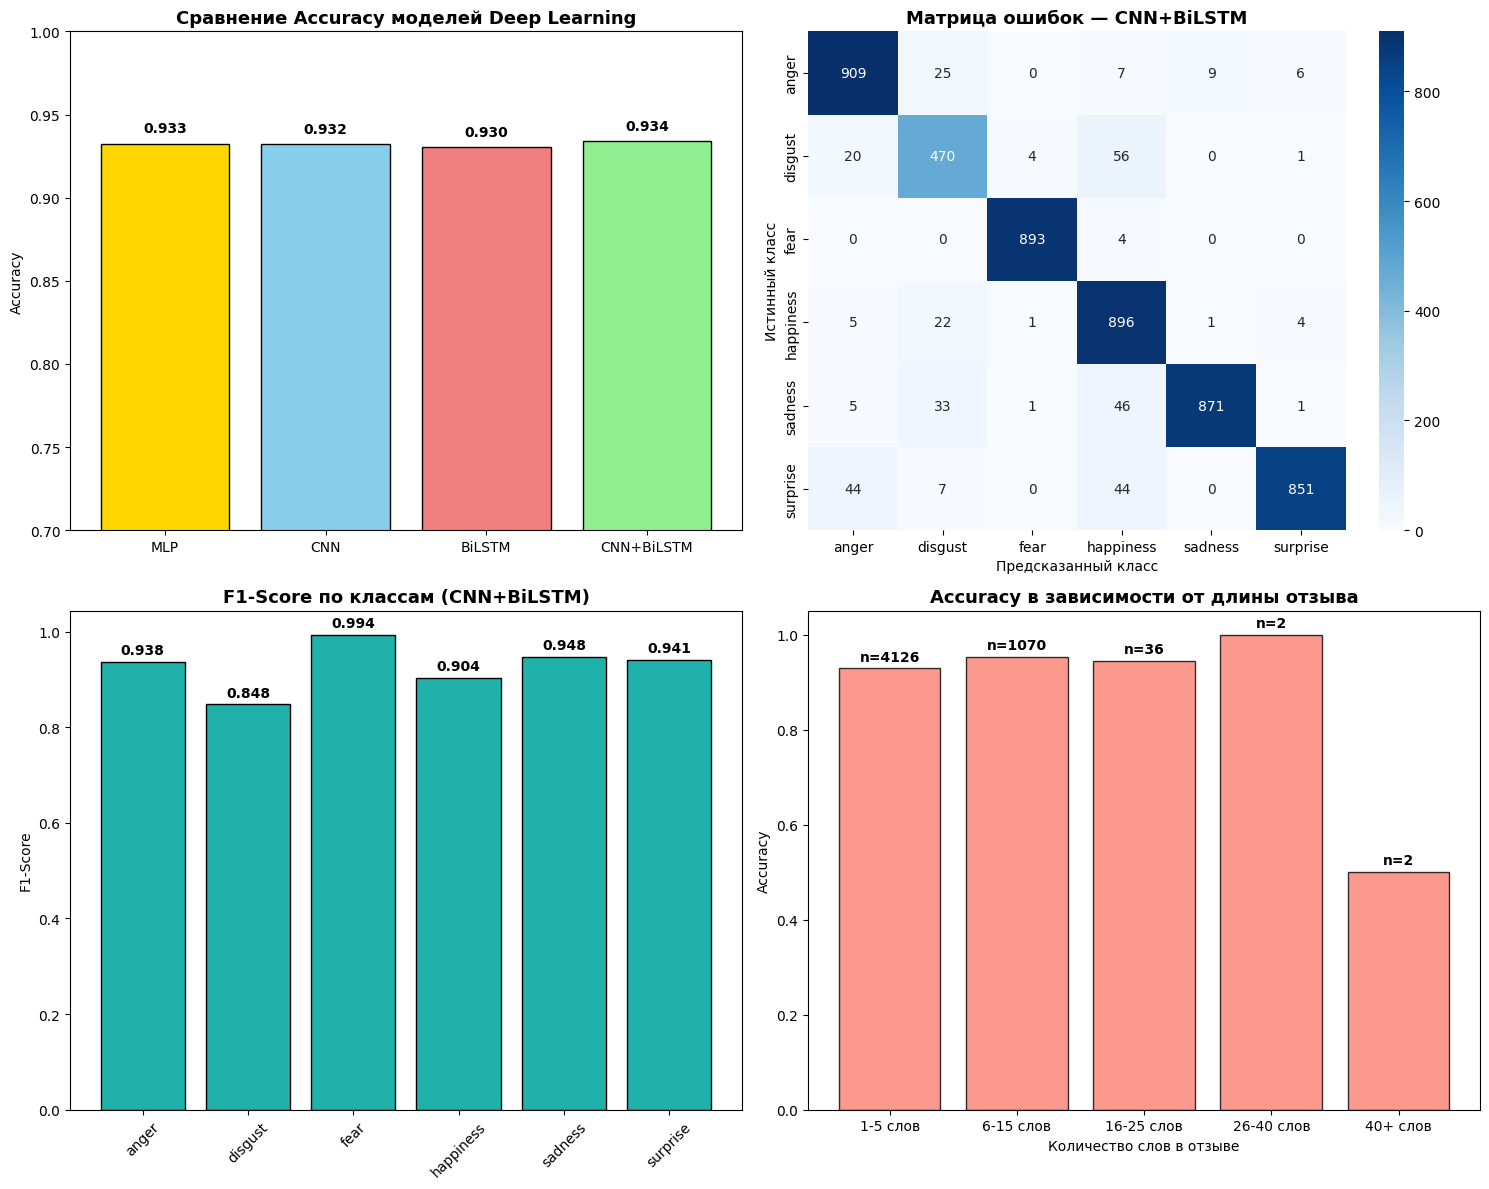


ИТОГОВАЯ СВОДКА РЕЗУЛЬТАТОВ АНАЛИЗА ЭМОЦИЙ (Deep Learning)
 Датасет: 26,176 примеров, 6 классов эмоций
 Лучшая модель: CNN+BiLSTM
 Accuracy: 0.9339 (93.39%)
 F1-Score (macro): 0.9289


In [27]:
# Итоговая визуализация результатов лучшей модели
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# 1. Сравнение accuracy моделей DL
model_names = ['MLP', 'CNN', 'BiLSTM', 'CNN+BiLSTM']
accuracies = [nn_accuracy, cnn_accuracy, bilstm_accuracy, hybrid_accuracy]
colors = ['gold', 'skyblue', 'lightcoral', 'lightgreen']
bars = ax1.bar(model_names, accuracies, color=colors, edgecolor='black')
ax1.set_title('Сравнение Accuracy моделей Deep Learning', fontweight='bold', fontsize=13)
ax1.set_ylabel('Accuracy'); ax1.set_ylim(0.7, 1.0)
for bar, acc in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

# 2. Матрица ошибок лучшей модели
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=emotions, yticklabels=emotions)
ax2.set_title(f'Матрица ошибок — {best_model_name}', fontweight='bold', fontsize=13)
ax2.set_xlabel('Предсказанный класс'); ax2.set_ylabel('Истинный класс')

# 3. F1-score по классам эмоций (лучшая модель)
f1_by_class = [class_report[e]['f1-score'] for e in emotions]
bars3 = ax3.bar(emotions, f1_by_class, color='lightseagreen', edgecolor='black')
ax3.set_title(f'F1-Score по классам ({best_model_name})', fontweight='bold', fontsize=13)
ax3.set_ylabel('F1-Score'); ax3.tick_params(axis='x', rotation=45)
for bar, score in zip(bars3, f1_by_class):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

# 4. Зависимость accuracy от длины текста
results_df['word_count'] = results_df['text'].str.split().str.len()
bins = pd.cut(results_df['word_count'], bins=5, labels=['1-5', '6-15', '16-25', '26-40', '40+'])
acc_by_len = results_df.groupby(bins, observed=False)['correct'].agg(['mean', 'count'])
bars4 = ax4.bar(range(len(acc_by_len)), acc_by_len['mean'], color='salmon', alpha=0.8, edgecolor='black')
ax4.set_title('Accuracy в зависимости от длины отзыва', fontweight='bold', fontsize=13)
ax4.set_ylabel('Accuracy'); ax4.set_xlabel('Количество слов в отзыве')
ax4.set_xticks(range(len(acc_by_len)))
ax4.set_xticklabels(['1-5 слов', '6-15 слов', '16-25 слов', '26-40 слов', '40+ слов'])
for i, (bar, count) in enumerate(zip(bars4, acc_by_len['count'])):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'n={int(count)}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# Итоговая сводка
print('\n' + '=' * 80)
print('ИТОГОВАЯ СВОДКА РЕЗУЛЬТАТОВ АНАЛИЗА ЭМОЦИЙ (Deep Learning)')
print('=' * 80)
print(f' Датасет: {len(df_processed):,} примеров, {num_classes} классов эмоций')
print(f' Лучшая модель: {best_model_name}')
print(f' Accuracy: {best["acc"]:.4f} ({best["acc"]*100:.2f}%)')
print(f' F1-Score (macro): {best["report"]["macro avg"]["f1-score"]:.4f}')

## 7. Демо практического применения

Функция предсказания эмоции для нового произвольного отзыва:

In [28]:
# Функция предсказания эмоции для нового текста (лучшая DL-модель)
def predict_emotion(text, model_name=best_model_name, label_enc=label_encoder):
    """
    Предсказывает эмоцию нового отзыва лучшей DL-моделью.
    Возвращает словарь: predicted_emotion, confidence, top_predictions,
    processed_text, model_used.
    """
    # Предобработка должна совпадать с обучающей
    cleaned_text = clean_text(text)
    final_text = remove_stopwords(cleaned_text)

    # Токенизация + padding
    seq = tokenizer.texts_to_sequences([final_text])
    pad = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')

    # Выбираем модель по имени
    if model_name == 'MLP':
        probs = nn_model.predict(pad, verbose=0)[0]
    elif model_name == 'CNN':
        probs = cnn_model.predict(pad, verbose=0)[0]
    elif model_name == 'BiLSTM':
        probs = bilstm_model.predict(pad, verbose=0)[0]
    else:
        probs = hybrid_model.predict(pad, verbose=0)[0]

    pred_idx = int(np.argmax(probs))
    top_idx = np.argsort(probs)[::-1][:3]
    return {
        'predicted_emotion': label_enc.classes_[pred_idx],
        'confidence': float(probs[pred_idx]),
        'top_predictions': [(label_enc.classes_[i], float(probs[i])) for i in top_idx],
        'processed_text': final_text,
        'model_used': model_name,
    }

# Тестируем на нескольких примерах
test_samples = [
    'Sản phẩm rất tốt, tôi rất hài lòng với chất lượng',
    'Hàng tệ quá, đóng gói không cẩn thận, bị vỡ mất rồi',
    'Giao hàng chậm quá, đặt một tuần rồi mà chưa có hàng',
    'Wao, không ngờ chất lượng lại tốt như vậy',
    'Buồn quá, mong đợi nhiều mà thất vọng',
    'Tại sao lại không có hướng dẫn sử dụng vậy?',
]

print('ДЕМО: ПРЕДСКАЗАНИЕ ЭМОЦИЙ ДЛЯ НОВЫХ ОТЗЫВОВ')
print('=' * 70)
for i, text in enumerate(test_samples, 1):
    result = predict_emotion(text)
    print(f'Отзыв {i}: {text}')
    print(f'   Модель: {result["model_used"]}')
    print(f'   Эмоция: {result["predicted_emotion"].upper()}')
    print(f'   Уверенность: {result["confidence"]:.3f}')
    print(f'   Текст после обработки: {result["processed_text"]}')
    print('   Топ-3 предсказания:')
    for emotion, prob in result['top_predictions']:
        print(f'     - {emotion}: {prob:.3f} ({prob*100:.1f}%)')
    print()

ДЕМО: ПРЕДСКАЗАНИЕ ЭМОЦИЙ ДЛЯ НОВЫХ ОТЗЫВОВ
Отзыв 1: Sản phẩm rất tốt, tôi rất hài lòng với chất lượng
   Модель: CNN+BiLSTM
   Эмоция: HAPPINESS
   Уверенность: 0.978
   Текст после обработки: sản_phẩm tốt hài_lòng chất_lượng
   Топ-3 предсказания:
     - happiness: 0.978 (97.8%)
     - surprise: 0.017 (1.7%)
     - disgust: 0.003 (0.3%)

Отзыв 2: Hàng tệ quá, đóng gói không cẩn thận, bị vỡ mất rồi
   Модель: CNN+BiLSTM
   Эмоция: DISGUST
   Уверенность: 0.758
   Текст после обработки: hàng tệ đóng_gói không cẩn_thận vỡ mất
   Топ-3 предсказания:
     - disgust: 0.758 (75.8%)
     - anger: 0.225 (22.5%)
     - happiness: 0.010 (1.0%)

Отзыв 3: Giao hàng chậm quá, đặt một tuần rồi mà chưa có hàng
   Модель: CNN+BiLSTM
   Эмоция: HAPPINESS
   Уверенность: 0.336
   Текст после обработки: giao hàng chậm đặt một tuần chưa hàng
   Топ-3 предсказания:
     - happiness: 0.336 (33.6%)
     - disgust: 0.250 (25.0%)
     - anger: 0.244 (24.4%)

Отзыв 4: Wao, không ngờ chất lượng lại tốt như vậy


In [29]:
# ============================================================
# Сохранение лучшей модели и компонентов для дальнейшего использования
# ============================================================

# Выбираем объект модели по имени лучшей
model_objects = {'MLP': nn_model, 'CNN': cnn_model,
                 'BiLSTM': bilstm_model, 'CNN+BiLSTM': hybrid_model}
best_keras_model = model_objects[best_model_name]

model_path = os.path.join(OUTPUT_DIR, 'sentiment_model_best.keras')
tokenizer_path = os.path.join(OUTPUT_DIR, 'tokenizer.pkl')
label_path = os.path.join(OUTPUT_DIR, 'label_encoder.pkl')
utils_path = os.path.join(OUTPUT_DIR, 'preprocess_utils.pkl')

best_keras_model.save(model_path)
with open(tokenizer_path, 'wb') as f:
    pickle.dump(tokenizer, f)
with open(label_path, 'wb') as f:
    pickle.dump(label_encoder, f)
with open(utils_path, 'wb') as f:
    pickle.dump({'clean_function': clean_text,
                 'stopwords_function': remove_stopwords,
                 'max_len': max_len}, f)

print('Модель и компоненты сохранены:')
print(f'  - Keras-модель:  {model_path}')
print(f'  - Токенизатор:   {tokenizer_path}')
print(f'  - LabelEncoder:  {label_path}')
print(f'  - Утилиты:       {utils_path}')

print('\nКак загрузить модель для предсказаний:')
print("""
import pickle, numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

model = load_model('artifacts/sentiment_model_best.keras')
with open('artifacts/tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)
with open('artifacts/label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)
with open('artifacts/preprocess_utils.pkl', 'rb') as f:
    utils = pickle.load(f)

def predict_new_text(text):
    cleaned = utils['clean_function'](text)
    final_text = utils['stopwords_function'](cleaned)
    seq = tokenizer.texts_to_sequences([final_text])
    pad = pad_sequences(seq, maxlen=utils['max_len'], padding='post', truncating='post')
    probs = model.predict(pad)[0]
    idx = int(np.argmax(probs))
    return label_encoder.classes_[idx], float(probs[idx])
""")

print('\n' + '=' * 80)
print('ЭКСПЕРИМЕНТ ЗАВЕРШЁН')
print(f'Результаты для отчёта: {RESULTS_DIR}/ (deep_models_metrics.csv,')
print('per_class_reports.json, best_model_analysis.json, test_predictions_best.csv)')
print('Скачайте эти файлы вместе с артефактами из Output-раздела Kaggle.')
print('=' * 80)

Модель и компоненты сохранены:
  - Keras-модель:  /kaggle/working/artifacts/sentiment_model_best.keras
  - Токенизатор:   /kaggle/working/artifacts/tokenizer.pkl
  - LabelEncoder:  /kaggle/working/artifacts/label_encoder.pkl
  - Утилиты:       /kaggle/working/artifacts/preprocess_utils.pkl

Как загрузить модель для предсказаний:

import pickle, numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

model = load_model('artifacts/sentiment_model_best.keras')
with open('artifacts/tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)
with open('artifacts/label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)
with open('artifacts/preprocess_utils.pkl', 'rb') as f:
    utils = pickle.load(f)

def predict_new_text(text):
    cleaned = utils['clean_function'](text)
    final_text = utils['stopwords_function'](cleaned)
    seq = tokenizer.texts_to_sequences([final_text])
    pad = pad_sequences(seq, maxlen=u